# **Race Gender and Nationality Analysis:**

In [72]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import plotly.io as pio
import warnings
warnings.filterwarnings('ignore')

In [73]:
data= pd.read_csv('data.csv')
data.shape

(42468, 14)

In [74]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


### **1. Gender Distribution:**

In [75]:
data["gender"].unique()

array(['Male', 'Female'], dtype=object)

In [76]:
data["gender"].value_counts().reset_index().rename(columns={"gender":"Gender","count":"Count"})

,Gender,Count
0,Male,27988
1,Female,14480


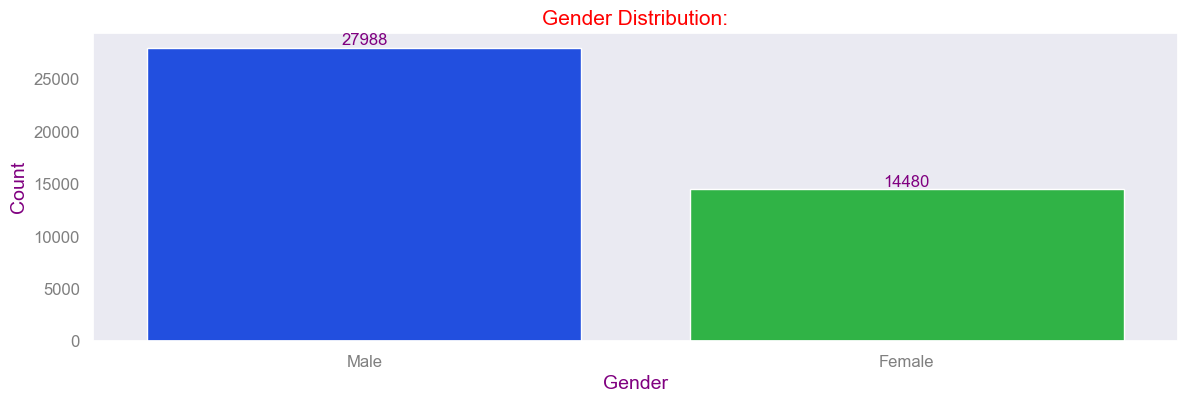

In [77]:
plt.figure(figsize=(14,4))
sns.set_style("dark") # or, 
sns.set_theme(style="dark", context= "notebook", )
sns.countplot(x="gender", data=data, palette='bright6', )
plt.title("Gender Distribution:", fontsize=15, color= "Red")
plt.xlabel("Gender", fontsize=14, color= "Purple")
plt.ylabel("Count", fontsize=14, color= "Purple")
plt.xticks(fontsize=12, color='gray')
plt.yticks(fontsize=12, color='gray')
# add annotations
for i, v in enumerate(data["gender"].value_counts()):
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=12, color='Purple')
plt.show()

Males significantly outnumber females in this dataset, with the male count appearing close to the top (near 25,000), while the female count is substantially lower (likely around 10,000–15,000). 

This stark disparity suggests a heavily male-dominated sample, which could reflect biases in the data collection or represent trends in a specific population (e.g., workforce demographics, survey respondents). The key takeaway is the pronounced gender imbalance, which may warrant further investigation.

---
---
---
----

### **2.  Gender vs Salary:**

In [78]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [79]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


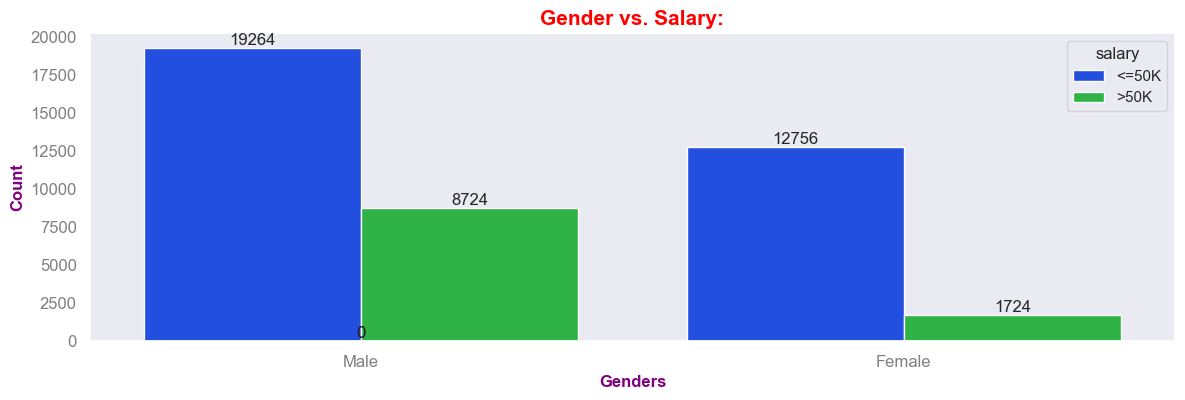

In [80]:
plt.figure(figsize=(14, 4))
sns.countplot(data=data, x="gender", hue="salary", palette="bright6")
plt.title("Gender vs. Salary:", color="Red", fontsize=15, fontweight="bold")
plt.xlabel("Genders", color="Purple", fontsize=12, fontweight="bold")
plt.ylabel("Count", color="Purple", fontsize=12, fontweight="bold")
plt.xticks(fontsize=12, color="gray")
plt.yticks(fontsize=12, color="gray")

# Add annotations on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                      (p.get_x() + p.get_width()/2., p.get_height()),
                      ha='center', va='bottom')

plt.show() 

* The chart displays the count of males and females categorized by their salary, specifically whether it's less than or equal to \$50K or greater than \$50K.

* A significantly higher number of males earn less than or equal to \$50K (19,264) compared to those earning over \$50K (8,724).

* For females, the majority also earn less than or equal to \$50K (12,756), with a much smaller number earning over \$50K (1,724).

* Overall, the data suggests that a higher proportion of individuals, both male and female, fall into the lower salary bracket ($<=\text{50K}$), and there's a clear disparity in higher earners, with males outnumbering females in the $>\text{50K}$ category.

---
---
----
----

### **3. Race Distribution:**

In [81]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [82]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [83]:
data["race"].unique()

array(['Black', 'White', 'Asian-Pac-Islander', 'Other',
       'Amer-Indian-Eskimo'], dtype=object)

In [84]:
rce= data["race"].value_counts().reset_index()
rce

,race,count
0,White,35541
1,Black,4536
2,Asian-Pac-Islander,1515
3,Amer-Indian-Eskimo,470
4,Other,406


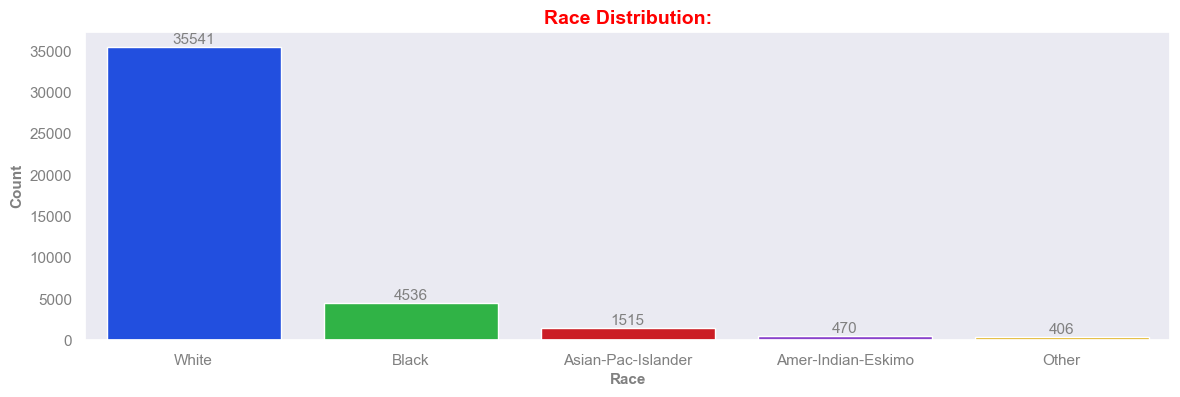

In [85]:
plt.figure(figsize=(14, 4))
sns.set_theme(style="dark", context= "notebook")
sns.barplot(data= rce, x= "race", y= "count", palette="bright6")
plt.title("Race Distribution:", fontsize= 14, fontweight= "bold", color= "Red")
plt.xlabel("Race", fontweight= "bold", fontsize= 11, color= "Gray")
plt.ylabel("Count", fontweight= "bold", fontsize= 11, color= "Gray")
plt.xticks(fontsize= 11, color= "Gray")
plt.yticks(fontsize= 11, color= "Gray")

# Add annotations: 
for p in plt.gca().patches:
    plt.gca().annotate(text= f'{int(p.get_height())}', 
                      xy= (p.get_x() + p.get_width()/2., p.get_height()),
                      ha='center', 
                      va='bottom', 
                      color= "gray", 
                      fontsize= 11, 
                      fontweight= "normal")

plt.show()

* The overwhelming majority of individuals in this dataset are identified as "White," with a count of 35,541.

* "Black" individuals form the second largest group, with a count of 4,536; the difference in count between first and second is too large.

* "Asian-Pac-Islander" is the third largest group, with 1,515 individuals.

* The categories "Amer-Indian-Eskimo" (470 individuals) and "Other" (406 individuals) represent the smallest proportions of the dataset.

---
---
----
----
------

### **4. Income by Race:**
Objective: Explore if income level differs by race.
How: Group by race and show the proportion of >50K earners.

In [86]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [87]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


In [95]:
nom_rc= data[["race", "salary"]].value_counts(normalize= True).reset_index()
nom_rc = nom_rc.rename(columns={0: "proportion"})
nom_rc

,race,salary,proportion
0,White,<=50K,0.616158
1,White,>50K,0.220731
2,Black,<=50K,0.093623
3,Asian-Pac-Islander,<=50K,0.026043
4,Black,>50K,0.013186
5,Amer-Indian-Eskimo,<=50K,0.009772
6,Asian-Pac-Islander,>50K,0.009631
7,Other,<=50K,0.008383
8,Amer-Indian-Eskimo,>50K,0.001295
9,Other,>50K,0.001177


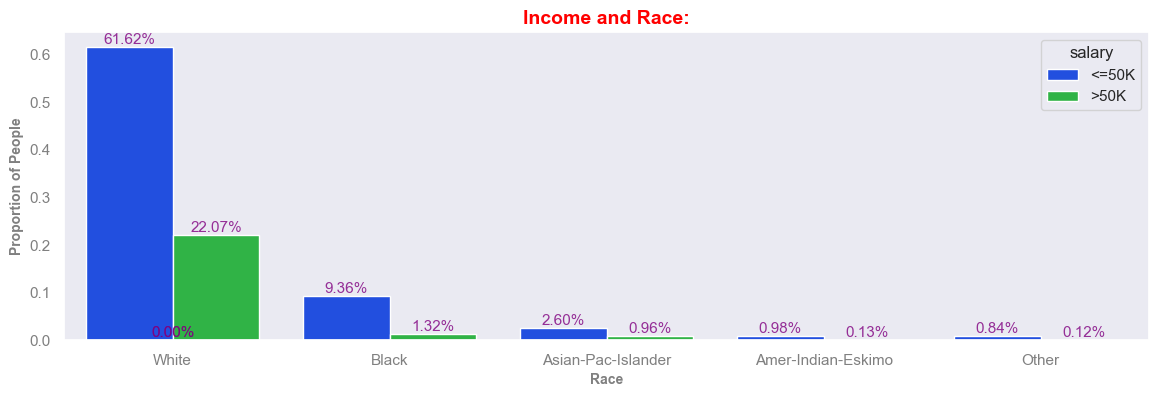

In [99]:
plt.figure(figsize=(14, 4))
sns.set_theme(style="dark", context= "notebook")
sns.barplot(data= nom_rc, hue= "salary", y= "proportion", x= "race", palette= "bright6")
#Add annotations:
for p in plt.gca().patches:
    plt.gca().annotate(text= f'{p.get_height():.2%}',
                      xy= (p.get_x() + p.get_width()/2., p.get_height()),
                      ha='center',
                      va='bottom',
                      color= "purple",
                      alpha= 0.8, 
                      fontsize= 11,
                      fontweight= "normal")
plt.xlabel("Race", fontsize= 11, fontweight= "bold", color= "gray")
plt.ylabel("Proportion of People", fontsize= 11, fontweight= "bold", color= "gray")
plt.xticks(fontsize= 11, color= "gray")
plt.yticks(fontsize= 11, color= "gray")
plt.title("Income and Race:", fontsize= 14, fontweight= "bold", color= "red")
plt.xlabel("Race", fontsize= 10, fontweight= "bold", color= "gray")
plt.ylabel("Proportion of People", fontsize= 10, fontweight= "bold", color= "gray")
plt.show()

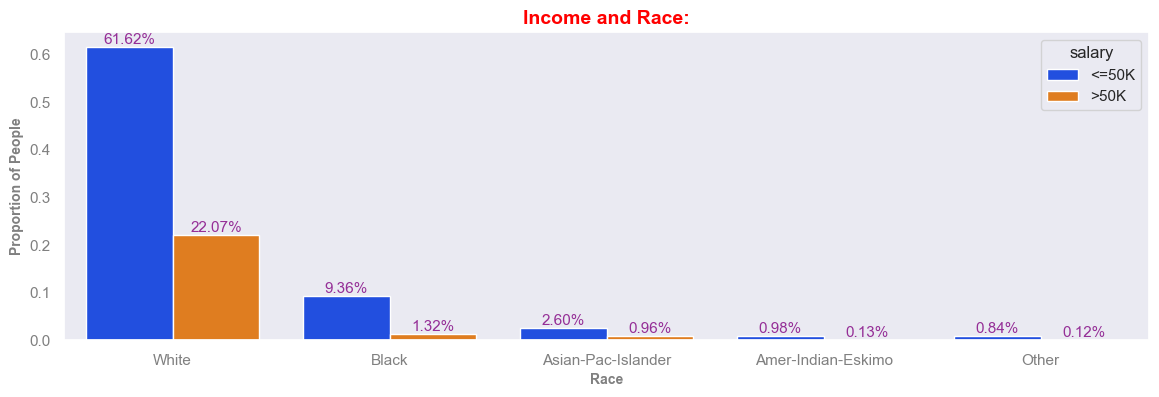

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(14, 4))
sns.set_theme(style="dark", context="notebook")
sns.barplot(data=nom_rc, hue="salary", y="proportion", x="race", palette="bright") # Using 'bright' palette as 'bright6' isn't standard

#Add annotations:
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0.0001:  # Only annotate if height is significantly greater than zero
        plt.gca().annotate(text=f'{height:.2%}',
                           xy=(p.get_x() + p.get_width()/2., height),
                           ha='center',
                           va='bottom',
                           color="purple",
                           alpha=0.8,
                           fontsize=11,
                           fontweight="normal")
    else:
        # Optional: Print to debug if a patch with very small height is encountered
        # print(f"Skipping annotation for bar with height: {height:.4f}")
        pass

plt.xlabel("Race", fontsize=11, fontweight="bold", color="gray")
plt.ylabel("Proportion of People", fontsize=11, fontweight="bold", color="gray")
plt.xticks(fontsize=11, color="gray")
plt.yticks(fontsize=11, color="gray")
plt.title("Income and Race:", fontsize= 14, fontweight= "bold", color= "red")
plt.xlabel("Race", fontsize= 10, fontweight= "bold", color= "gray")
plt.ylabel("Proportion of People", fontsize= 10, fontweight= "bold", color= "gray")
plt.show()

* **White** individuals constitute the largest proportion in both salary categories, with 61.62% earning $<=\text{50K}$ and 22.07% earning $>\text{50K}$.

* For all other racial groups (Black, Asian-Pac-Islander, Amer-Indian-Eskimo, and Other), the proportion of individuals earning $<=\text{50K}$ is significantly higher than those earning $>\text{50K}$.

* **Black** individuals represent 9.36% earning $<=\text{50K}$ and 1.32% earning $>\text{50K}$.

* The proportions for **Asian-Pac-Islander**, **Amer-Indian-Eskimo**, and **Other** racial groups are relatively small across both salary brackets, with very few individuals earning $>\text{50K}$.

---
-----
----
----
----

### **5. Gender vs Capital Gain:** 

Objective: See if there's a gap in capital gains across genders.
How: Boxplot or bar chart comparing average capital-gain by gender.

In [100]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [ ]:
data[["capital-gain", "gender"]].dtypes

capital-gain     int64
gender          object
dtype: object

In [102]:
data[["capital-gain", "gender"]]

,capital-gain,gender
0,0,Male
1,0,Male
2,0,Male
3,7688,Male
4,0,Female
...,...,...
42463,0,Male
42464,0,Male
42465,0,Female
42466,0,Female


In [107]:
data[["capital-gain", "gender"]].nunique()

capital-gain    123
gender            2
dtype: int64

In [130]:
dass= data.groupby("gender")["capital-gain"].mean().reset_index()
dass

,gender,capital-gain
0,Female,649.386740
1,Male,1524.648742


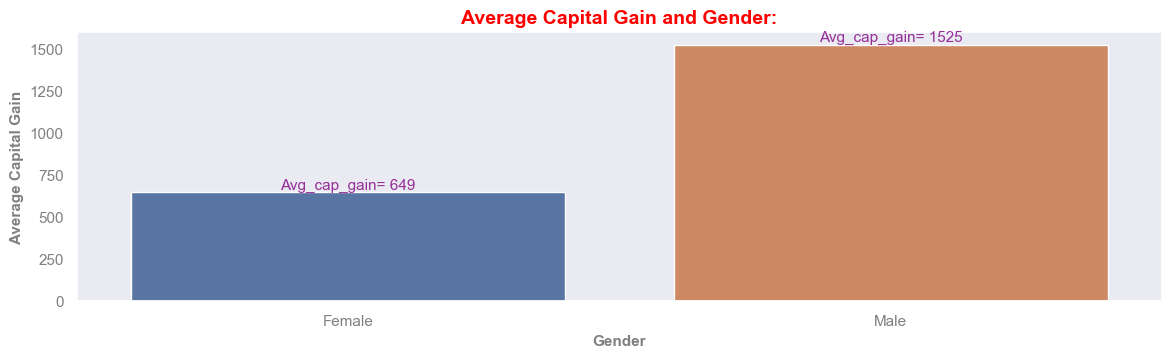

In [154]:
plt.figure(figsize= (14, 3.5))
sns.barplot(data= dass, x= "gender", y= "capital-gain", hue= "gender", legend= False)
plt.title("Average Capital Gain and Gender:", fontsize= 14, fontweight= "bold", color= "Red")
plt.xlabel("Gender", fontsize= 11, fontweight= "bold", color= "gray")
plt.ylabel("Average Capital Gain", fontsize= 11, fontweight= "bold", color= "gray")
plt.xticks(fontsize= 11, color= "gray")
plt.yticks(fontsize= 11, color= "gray")
# add annotation on each bar top: 
#Add annotations:
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(text=f'Avg_cap_gain= {round(height)}',
                           xy=(p.get_x() + p.get_width()/2., height),
                           ha='center',
                           va='bottom',
                           color="purple",
                           alpha=0.8,
                           fontsize=11,
                           fontweight="normal")
plt.show()

The barplot compares the average capital gain for each genders. Each bar’s height (`males: 1525` and `females: 649`) represents the computed mean capital gain, clearly showing a huge gap between the genders.

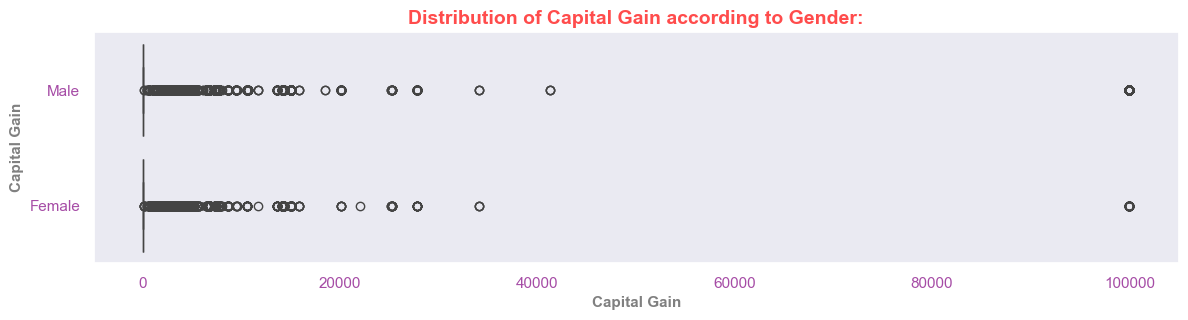

In [153]:
plt.figure(figsize= (14, 3))
sns.boxplot(data= data, y= "gender", x= "capital-gain", palette= "bright6")
plt.title("Distribution of Capital Gain according to Gender:", color= "red", fontsize= 14, fontweight= "bold", alpha= 0.7)
plt.xlabel("Capital Gain", color= "gray", fontsize= 11, fontweight= "bold")
plt.ylabel("Capital Gain", color= "gray", fontsize= 11, fontweight= "bold")
plt.xticks(fontsize= 11, color= "Purple", alpha= 0.7)
plt.yticks(fontsize= 11, color= "Purple", alpha= 0.7)
plt.show()

* **Most individuals**, both male and female, report **zero capital gain**.

* There are **several outliers** with high capital gains, especially around **10,000 to 100,000**.

* **Capital gain distribution** is **highly right-skewed**, with a small number of people earning significantly more.

* Both **genders show similar patterns** in capital gain distribution, but **males appear slightly more represented** among the higher outliers.

* The data suggests that **capital gains are rare** and concentrated among a few individuals, with **no clear gender-based trend** in the overall distribution.